In [1]:
#Imports and settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (10,6)
RANDOM_STATE = 42

In [2]:
# Adjust display settings for nicer outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

In [3]:
# Load dataset
df = pd.read_csv("synthetic_heart_disease_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 21)


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,0,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,1,1,0,0,0,164,67,108,116,220,1


In [4]:
# Quick dataset overview
print("Columns:", df.columns.tolist())
print("\nInfo:")
display(df.info())
print("\nDescriptive statistics (numeric):")
display(df.describe().T)
print("\nTarget distribution:")
display(df['Heart_Disease'].value_counts(normalize=True).rename('proportion'))


Columns: ['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-nul

None


Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
Age,50000.0,54.464060,14.438090,30.0,42.0,54.0,67.0,79.0
Weight,50000.0,84.547520,20.213257,50.0,67.0,85.0,102.0,119.0
Height,50000.0,174.460000,14.420379,150.0,162.0,174.0,187.0,199.0
BMI,50000.0,28.984284,6.367494,18.0,23.5,29.0,34.5,40.0
Hypertension,50000.0,0.299620,0.458096,0.0,0.0,0.0,1.0,1.0
Diabetes,50000.0,0.199260,0.399448,0.0,0.0,0.0,0.0,1.0
Hyperlipidemia,50000.0,0.251660,0.433971,0.0,0.0,0.0,1.0,1.0
Family_History,50000.0,0.400500,0.490005,0.0,0.0,0.0,1.0,1.0
Previous_Heart_Attack,50000.0,0.099280,0.299041,0.0,0.0,0.0,0.0,1.0
Systolic_BP,50000.0,139.299580,23.083544,100.0,119.0,139.0,159.0,179.0



Target distribution:


Heart_Disease
0    0.53654
1    0.46346
Name: proportion, dtype: float64

In [5]:
# Data cleaning: duplicates and missing values
# Duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates. New shape:", df.shape)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values per column (if any):")
display(missing)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Duplicate rows: 0

Missing values per column (if any):


Alcohol_Intake    20109
dtype: int64


Numeric columns: ['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease']
Categorical columns: ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level']


In [6]:
# Impute missing values 
for c in df.columns:
    if df[c].isnull().any():
        if df[c].dtype in [np.float64, np.int64]:
            med = df[c].median()
            df[c] = df[c].fillna(med)
            print(f"Filled numeric {c} with median = {med}")
        else:
            mode = df[c].mode()[0]
            df[c] = df[c].fillna(mode)
            print(f"Filled categorical {c} with mode = {mode}")

print("Missing values after imputation:", df.isnull().sum().sum())

Filled categorical Alcohol_Intake with mode = Low
Missing values after imputation: 0


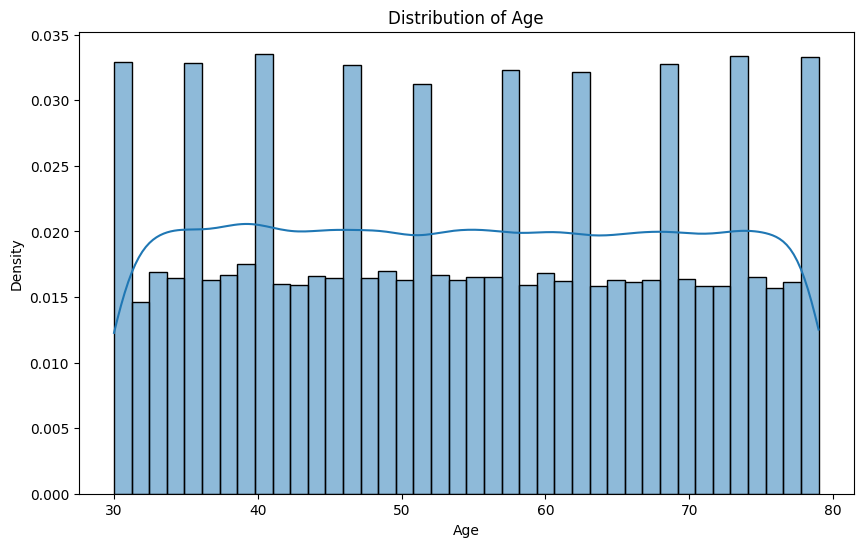

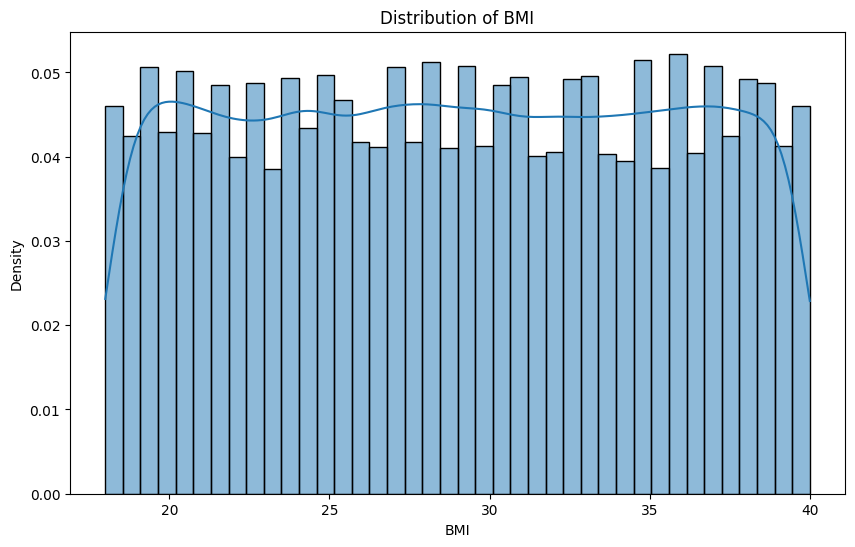

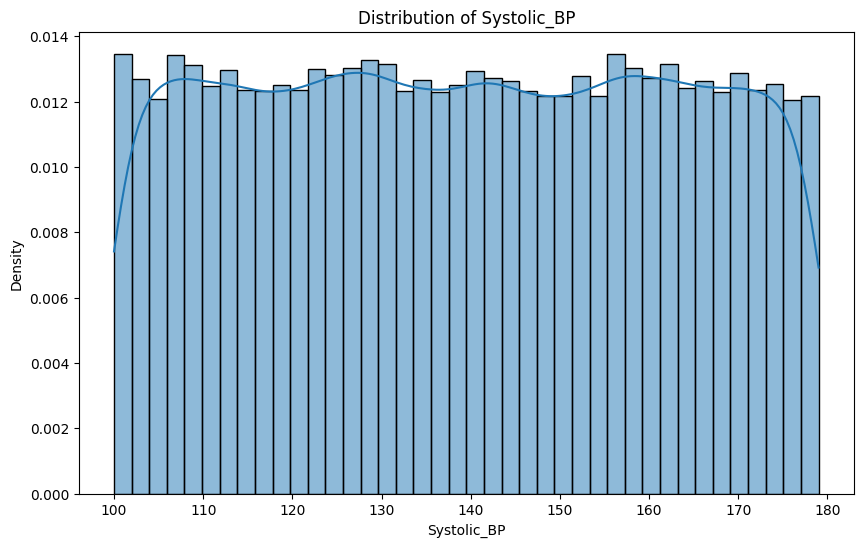

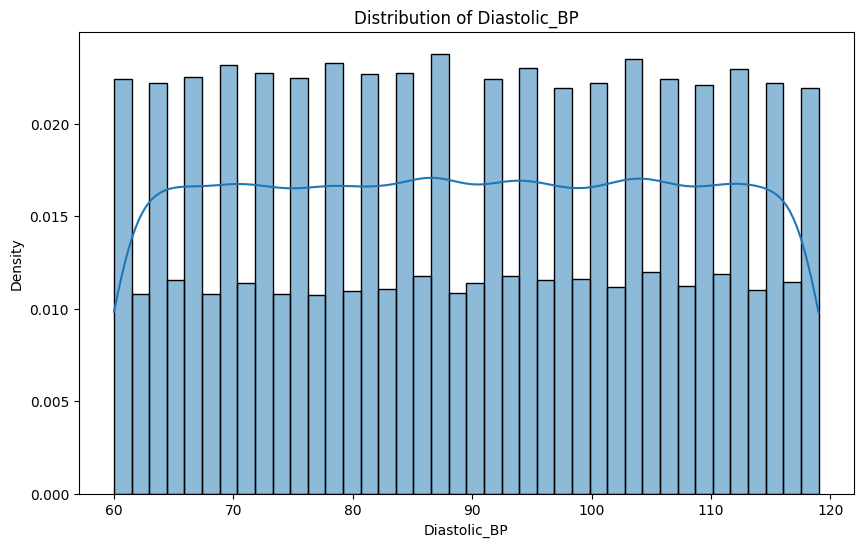

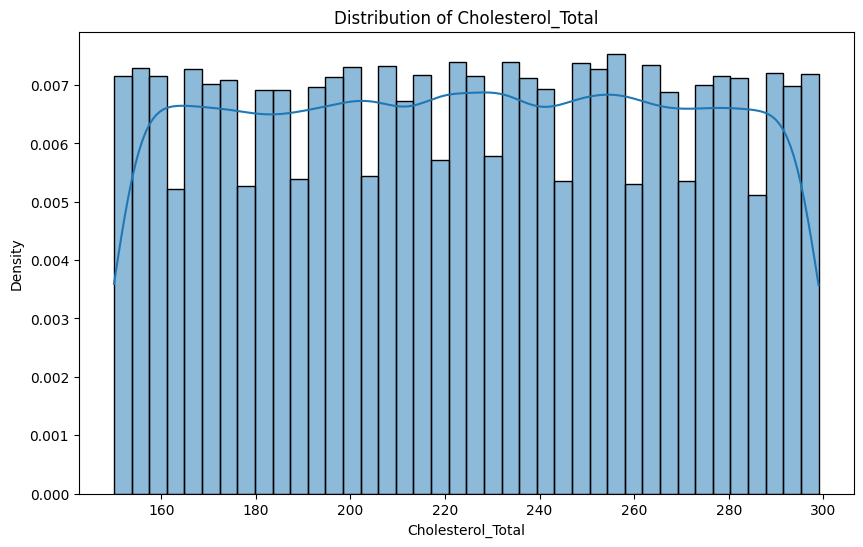

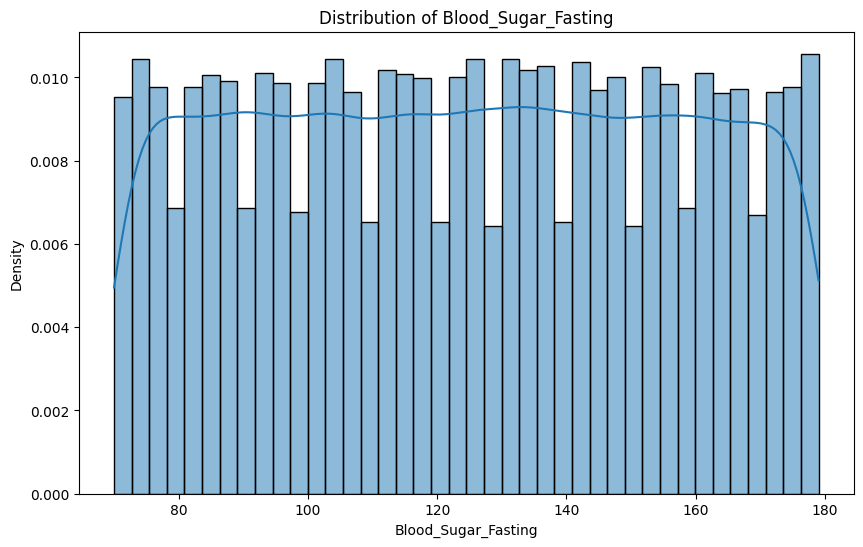

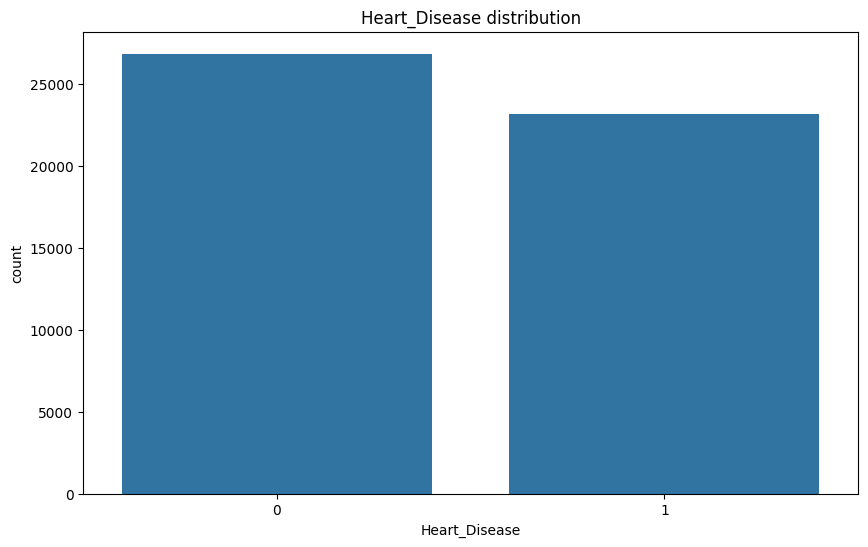

In [7]:
# Basic EDA / Visualization 1: Distributions of some numeric columns and target
numeric_to_plot = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Blood_Sugar_Fasting']
for col in numeric_to_plot:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col], kde=True, stat="density", bins=40)
        plt.title(f"Distribution of {col}")
        plt.show()

# Target countplot
plt.figure()
sns.countplot(x='Heart_Disease', data=df)
plt.title("Heart_Disease distribution")
plt.show()


In [8]:
# Removing outliers using IQR method
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[(df[col] >= lower) & (df[col] <= upper)]

In [9]:
# Reduce skewness using log transform
for col in num_cols:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])

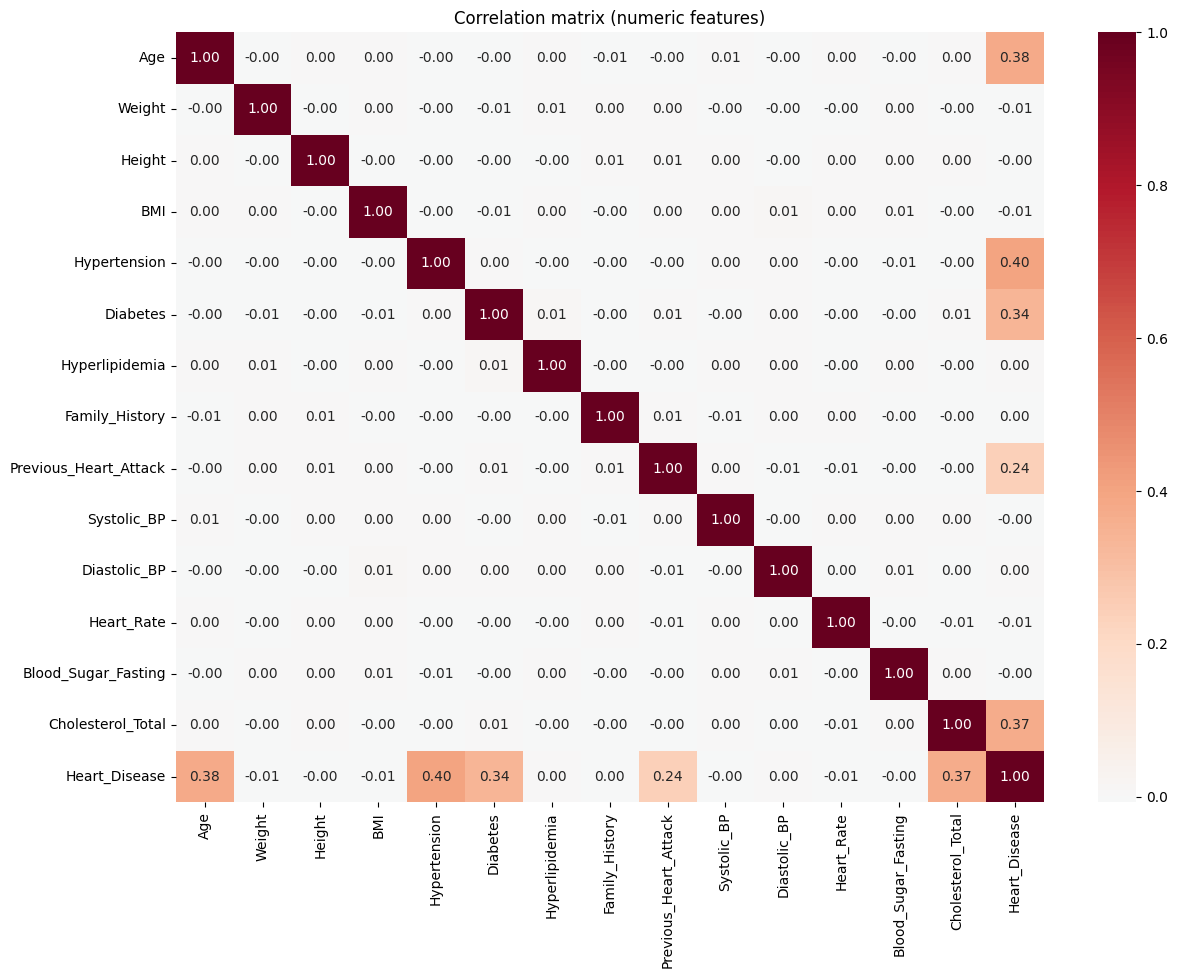

In [10]:
# Correlation matrix for numeric features
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

In [11]:
# Feature engineering / create feature lists
# We'll keep original features. Define categorical and numeric lists for preprocessing
target_col = 'Heart_Disease'

categorical_features = [c for c in df.select_dtypes(include=['object', 'category']).columns.tolist()]
if target_col in categorical_features:
    categorical_features.remove(target_col)

numeric_features = [c for c in df.select_dtypes(include=[np.number]).columns.tolist() if c != target_col]

print("Categorical features to encode:", categorical_features)
print("Numeric features to scale:", numeric_features)


Categorical features to encode: ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level']
Numeric features to scale: ['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total']


In [12]:
# Label Encoding all categorical columns as requested
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: classes -> {le.classes_}")

df_encoded.head()

Gender: classes -> ['Female' 'Male']
Smoking: classes -> ['Current' 'Former' 'Never']
Alcohol_Intake: classes -> ['High' 'Low' 'Moderate']
Physical_Activity: classes -> ['Active' 'Moderate' 'Sedentary']
Diet: classes -> ['Average' 'Healthy' 'Unhealthy']
Stress_Level: classes -> ['High' 'Low' 'Medium']


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,1,2,1,2,0,0.000000,0.693147,1,0.0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,1,0,0,0,1,0.000000,0.693147,1,0.0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,1,1,0,2,0,0.000000,0.000000,1,0.0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,2,1,0,1,0,0.000000,0.693147,0,0.0,171,92,109,105,290,1
4,34,0,65,191,18.5,0,1,2,1,1,1,0.693147,0.000000,0,0.0,164,67,108,116,220,1


In [13]:
# MinMax scaling for numeric columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_scaled = df_encoded.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])

# Save column lists for later
X = df_scaled.drop(columns=[target_col])
y = df_scaled[target_col].astype(int)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (50000, 20)
Target vector shape: (50000,)


In [14]:
print(df.columns)

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History',
       'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Step 1 — Base model with L1 (Lasso)
log_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Step 2 — Pipeline
pipe = Pipeline([
    ('feature_selection', SelectFromModel(log_model)),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Step 3 — Hyperparameter grid
param_grid = {
    'feature_selection__estimator__C': [0.01, 0.1, 1, 10, 100],
    'model__C': [0.01, 0.1, 1, 10,100]
}

# Step 4 — GridSearch
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Step 5 — Extract selected features
best_selector = grid.best_estimator_.named_steps['feature_selection']

selected_features = X.columns[best_selector.get_support()]

print("\nSelected Features:", list(selected_features))
print("Number of Selected Features:", len(selected_features))

# Step 6 — Transform dataset
X_selected = best_selector.transform(X)
X = pd.DataFrame(X_selected, columns=selected_features)

print("New Shape:", X.shape)

Best Parameters: {'feature_selection__estimator__C': 0.01, 'model__C': 0.1}
Best CV Accuracy: 0.9252800000000001

Selected Features: ['Age', 'Smoking', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes', 'Previous_Heart_Attack', 'Cholesterol_Total']
Number of Selected Features: 9
New Shape: (50000, 9)


In [16]:
X = X_selected
y = df_scaled['Heart_Disease']
X

array([[0.36734694, 2.        , 2.        , ..., 0.        , 0.        ,
        0.33557047],
       [0.10204082, 2.        , 0.        , ..., 0.        , 0.        ,
        0.37583893],
       [1.        , 2.        , 1.        , ..., 0.        , 0.        ,
        0.38926174],
       ...,
       [0.16326531, 1.        , 1.        , ..., 0.        , 0.        ,
        0.5704698 ],
       [0.7755102 , 2.        , 1.        , ..., 0.        , 0.        ,
        0.18120805],
       [0.46938776, 2.        , 1.        , ..., 0.        , 0.        ,
        0.87248322]], shape=(50000, 9))

In [17]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (40000, 9) Test shape: (10000, 9)


In [18]:
#Importing models for training and testing
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, classification_report, roc_curve, auc, f1_score, recall_score

In [19]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# Metrics
print("----- Logistic Regression -----")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

----- Logistic Regression -----
Accuracy: 0.9236
Precision: 0.9175836030204962
Recall: 0.9175836030204962
F1 Score: 0.9175836030204962

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5365
           1       0.92      0.92      0.92      4635

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



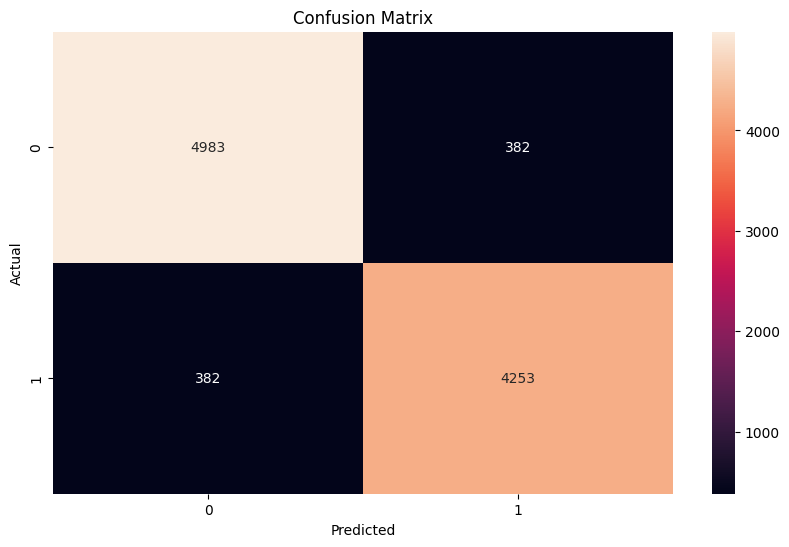

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

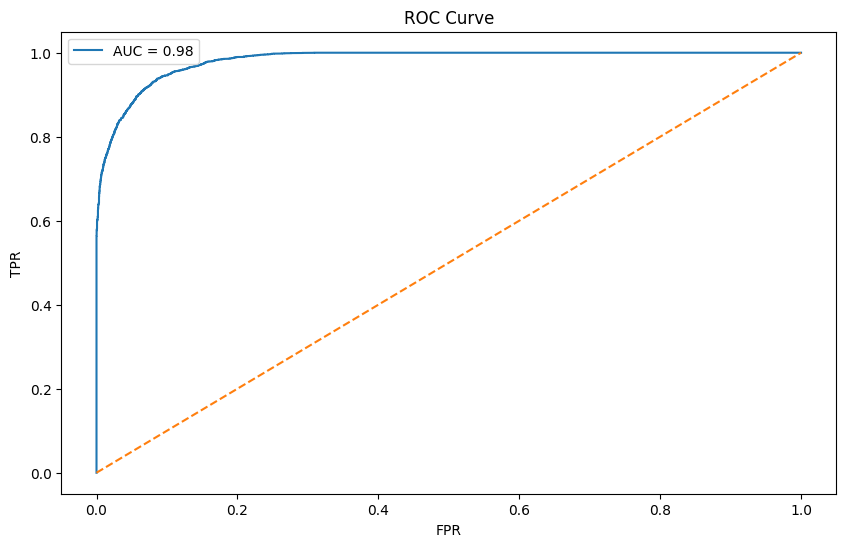

In [21]:
# ROC Curve
y_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [22]:
accuracy_list = []

for k in range(3, 21, 2):  # only odd values, skip 1
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append((k, acc))

# Find best K
best_k = max(accuracy_list, key=lambda x: x[1])

print("Best K:", best_k[0])
print("Accuracy:", best_k[1])

Best K: 3
Accuracy: 0.973


In [23]:
# KNN
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
# Metrics
print("----- KNN -----")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

----- KNN -----
Accuracy: 0.9574
Precision: 0.9503530922319708
Recall: 0.9581445523193096
F1 Score: 0.9542329179200688

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      5365
           1       0.95      0.96      0.95      4635

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



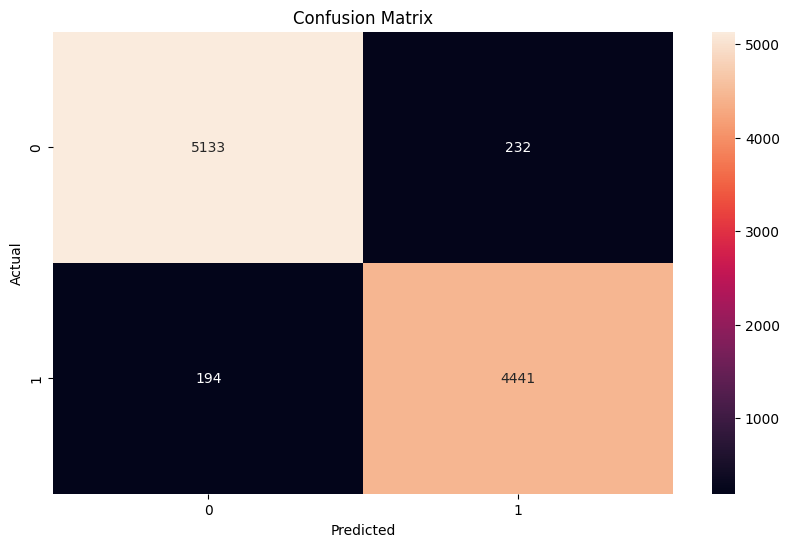

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

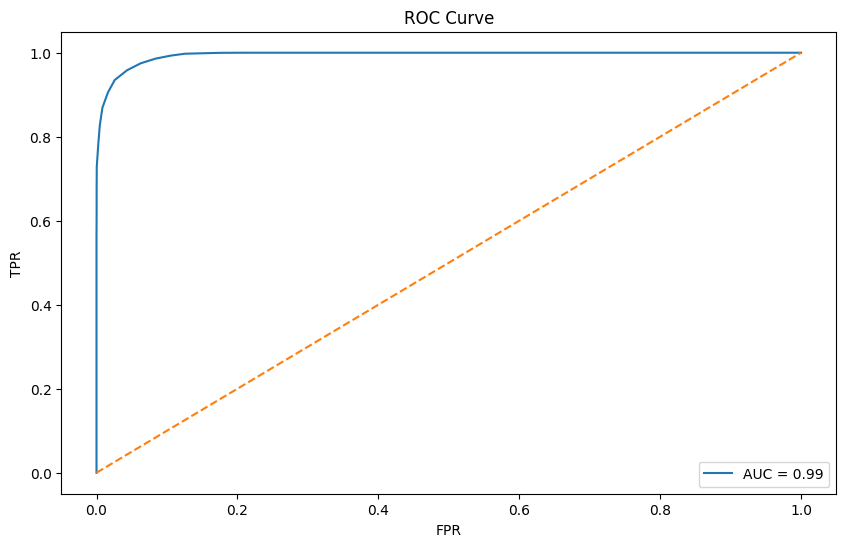

In [25]:
# ROC Curve
y_prob = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
# SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
# Metrics
print("----- SVM -----")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9327
----- SVM -----
Accuracy: 0.9327
Precision: 0.929159445407279
Recall: 0.9253505933117584
F1 Score: 0.9272511079883256

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      5365
           1       0.93      0.93      0.93      4635

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



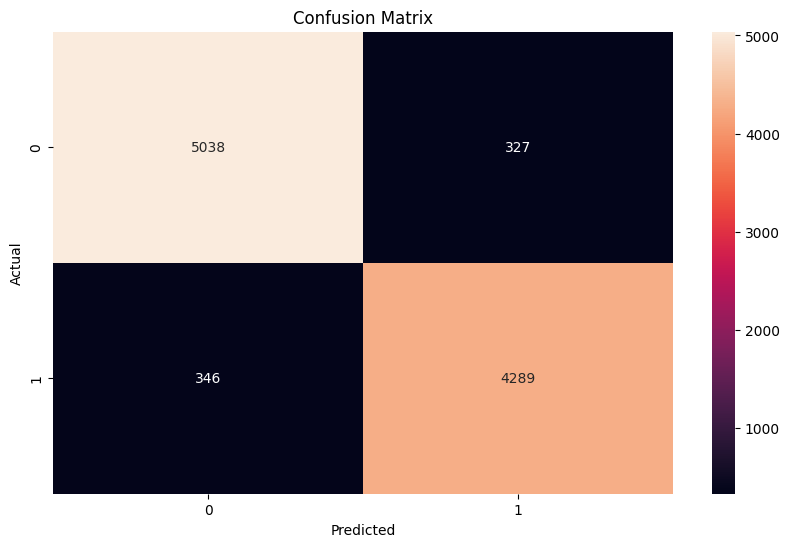

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

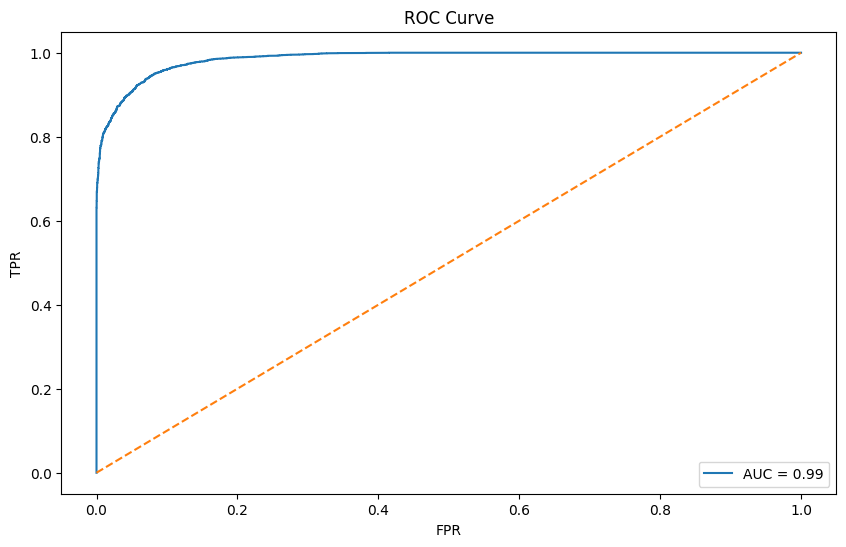

In [28]:
# ROC Curve
y_prob = svm.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


 Testing Kernel: linear
Accuracy: 0.9239
Precision: 0.9165591397849462
Recall: 0.9195253505933118
F1 Score: 0.9180398492191707

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5365
           1       0.92      0.92      0.92      4635

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



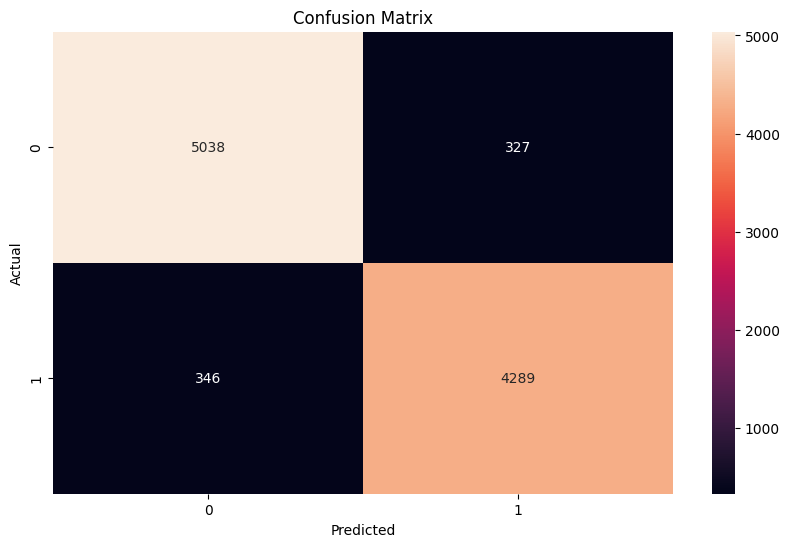


 Testing Kernel: poly
Accuracy: 0.9343
Precision: 0.9346590909090909
Recall: 0.9227615965480043
F1 Score: 0.9286722397133862

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      5365
           1       0.93      0.92      0.93      4635

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



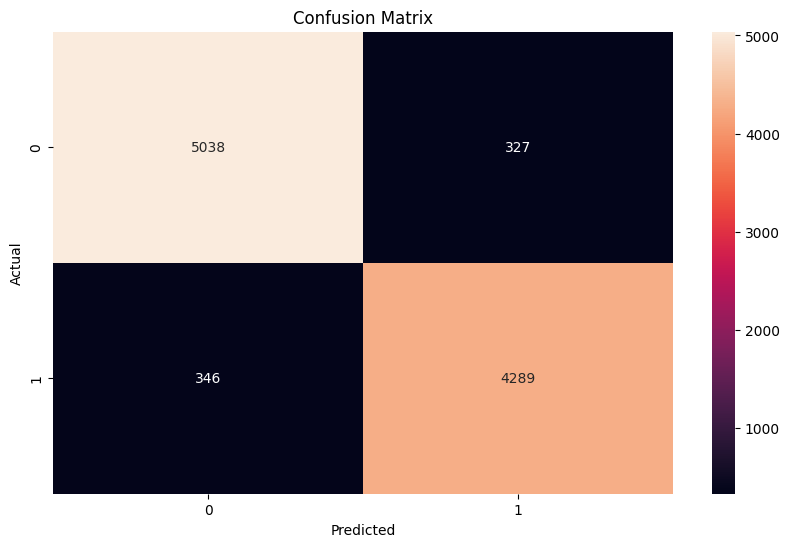


 Testing Kernel: rbf
Accuracy: 0.9327
Precision: 0.929159445407279
Recall: 0.9253505933117584
F1 Score: 0.9272511079883256

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      5365
           1       0.93      0.93      0.93      4635

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



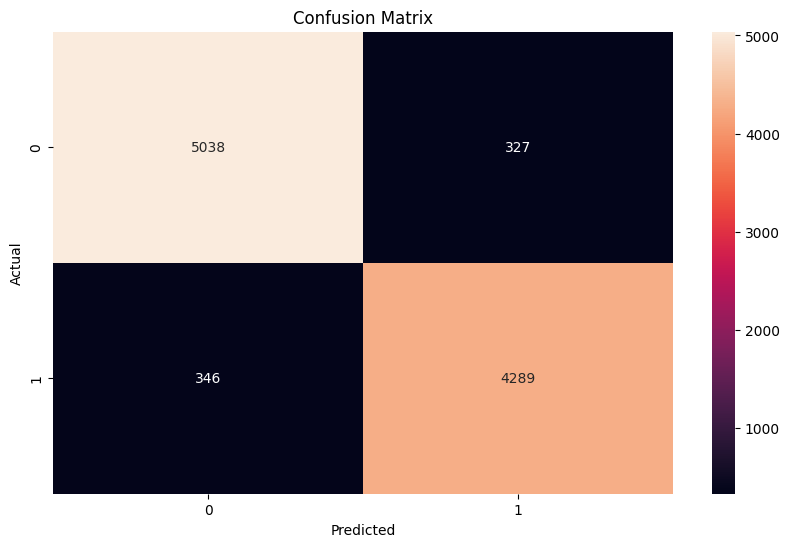


BEST MODEL RESULTS
Best Kernel: poly
Best Accuracy: 0.9343


In [29]:
# SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
# List of kernels to try
kernels = ['linear', 'poly', 'rbf']
best_model = None
best_kernel = None
best_accuracy = 0
# Loop through each kernel
for k in kernels:
    print(f"\n Testing Kernel: {k}")

    # Create model
    svm = SVC(kernel=k, probability=True)
    
    # Train model
    svm.fit(X_train, y_train)
    
    # Predictions
    y_pred = svm.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
   # print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred_svm)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Save best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = svm
        best_kernel = k

# Final Best Result
print("\nBEST MODEL RESULTS")
print("Best Kernel:", best_kernel)
print("Best Accuracy:", best_accuracy)

In [30]:
# Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
# Metrics
print("----- Extra Trees -----")
print("Accuracy:", accuracy_score(y_test, y_pred_et))
print("Precision:", precision_score(y_test, y_pred_et))
print("Recall:", recall_score(y_test, y_pred_et))
print("F1 Score:", f1_score(y_test, y_pred_et))
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_et,digits=6))

----- Extra Trees -----
Accuracy: 0.9963
Precision: 0.9961156668105309
Recall: 0.9959007551240561
F1 Score: 0.9960081993742583

Classification Report:
               precision    recall  f1-score   support

           0   0.996459  0.996645  0.996552      5365
           1   0.996116  0.995901  0.996008      4635

    accuracy                       0.996300     10000
   macro avg   0.996287  0.996273  0.996280     10000
weighted avg   0.996300  0.996300  0.996300     10000



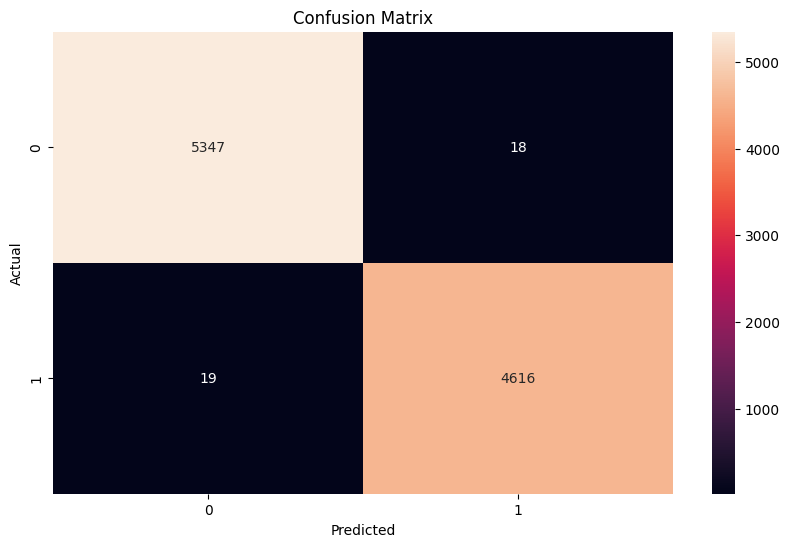

In [31]:
# Confusion Matrix
cm_et = confusion_matrix(y_test, y_pred_et)
sns.heatmap(cm_et, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

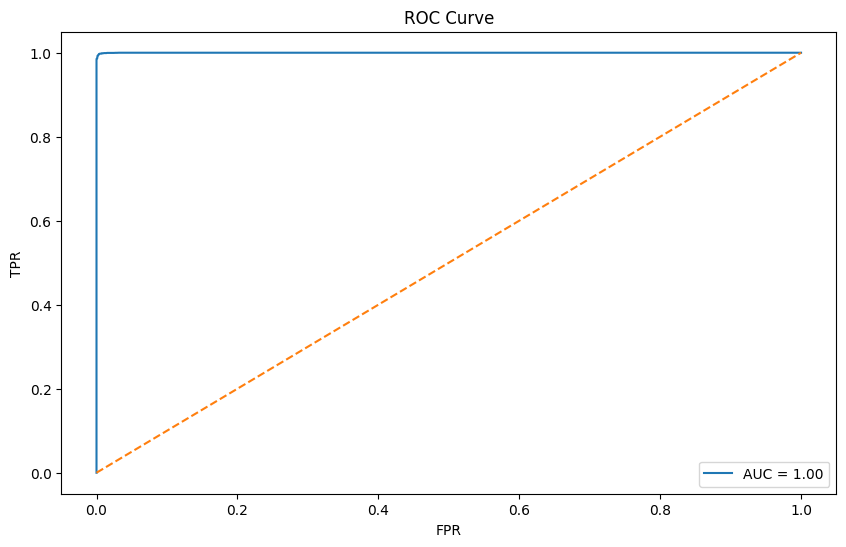

In [32]:
# ROC Curve
y_prob = et.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

# Metrics
print("----- Gaussian Naive Bayes -----")
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("Precision:", precision_score(y_test, y_pred_gnb))
print("Recall:", recall_score(y_test, y_pred_gnb))
print("F1 Score:", f1_score(y_test, y_pred_gnb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_gnb))

----- Gaussian Naive Bayes -----
Accuracy: 0.8359
Precision: 0.8468489341983317
Recall: 0.7885652642934197
F1 Score: 0.8166685286560161

Confusion Matrix:
 [[4704  661]
 [ 980 3655]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      5365
           1       0.85      0.79      0.82      4635

    accuracy                           0.84     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.84      0.84     10000



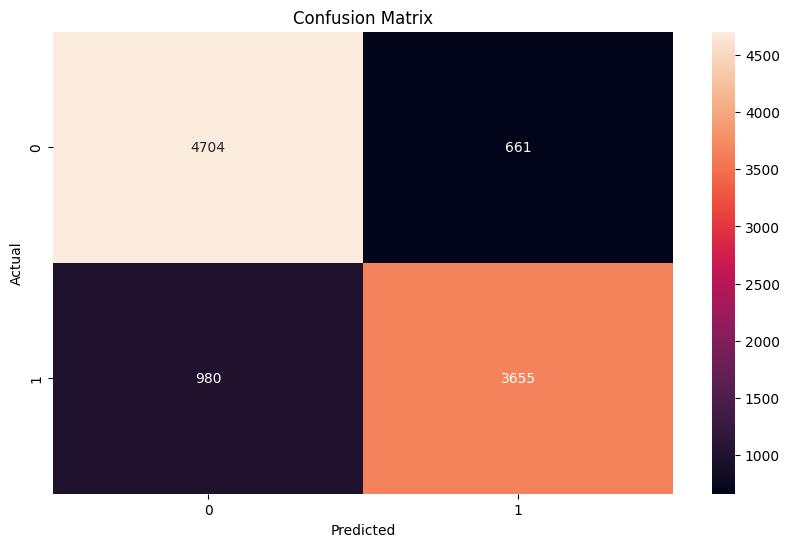

In [35]:
# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

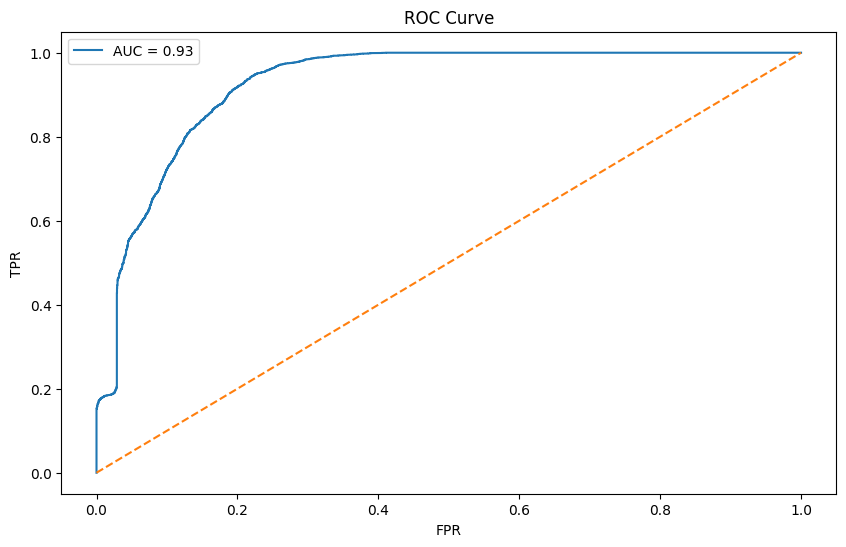

In [36]:
# ROC Curve
y_prob = gnb.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
# Model Comparsion
print("Model Comparison:")
print("Logistic:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Extra Trees Classifier:", accuracy_score(y_test, y_pred_et))
print("Gaussian Naive Bayes:", accuracy_score(y_test, y_pred_gnb))

Model Comparison:
Logistic: 0.9236
KNN: 0.9574
SVM: 0.9327
Extra Trees Classifier: 0.9963
Gaussian Naive Bayes: 0.8359


In [38]:
results = {}
results["Logistic"] = accuracy_score(y_test, y_pred_lr)
results["KNN"] = accuracy_score(y_test, y_pred_knn)
results["SVM"] = accuracy_score(y_test, y_pred_svm)
results["Extra Trees"] = accuracy_score(y_test, y_pred_et)
results["Gaussian Naive Bayes"] = accuracy_score(y_test, y_pred_gnb)

In [39]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

Best Model: Extra Trees
Best Accuracy: 0.9963


In [40]:
import pickle

models = {
     'lr': lr,
     'knn': knn,
     'svm': svm,
     'et': et,
     'GNB': gnb
}

for name, model in models.items():
    with open(f'{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

In [41]:
for col in categorical_features:
    print(col, "->", label_encoders[col].classes_)
    

Gender -> ['Female' 'Male']
Smoking -> ['Current' 'Former' 'Never']
Alcohol_Intake -> ['High' 'Low' 'Moderate']
Physical_Activity -> ['Active' 'Moderate' 'Sedentary']
Diet -> ['Average' 'Healthy' 'Unhealthy']
Stress_Level -> ['High' 'Low' 'Medium']


In [42]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)